In [14]:
# Integrating multi-omics features for breast cancer classification
# TCGA-BRCA Dataset from Kaggle

In [15]:
import os
os.chdir("/Users/zahinpeerzade/Desktop/BRCA")

In [16]:
import pandas as pd

df = pd.read_csv("/Users/zahinpeerzade/Desktop/BRCA/data/brca_data_w_subtypes.csv")
print(df.shape)
print(df.columns[:10])
df.head()

(705, 1941)
Index(['rs_CLEC3A', 'rs_CPB1', 'rs_SCGB2A2', 'rs_SCGB1D2', 'rs_TFF1',
       'rs_MUCL1', 'rs_GSTM1', 'rs_PIP', 'rs_ADIPOQ', 'rs_ADH1B'],
      dtype='object')


,rs_CLEC3A,rs_CPB1,rs_SCGB2A2,rs_SCGB1D2,rs_TFF1,rs_MUCL1,rs_GSTM1,rs_PIP,rs_ADIPOQ,rs_ADH1B,...,pp_p62.LCK.ligand,pp_p70S6K,pp_p70S6K.pT389,pp_p90RSK,pp_p90RSK.pT359.S363,vital.status,PR.Status,ER.Status,HER2.Final.Status,histological.type
0,0.892818,6.580103,14.123672,10.606501,13.189237,6.649466,10.520335,10.338490,10.248379,10.229970,...,-0.691766,-0.337863,-0.178503,0.011638,-0.207257,0,Positive,Positive,Negative,infiltrating ductal carcinoma
1,0.000000,3.691311,17.116090,15.517231,9.867616,9.691667,8.179522,7.911723,1.289598,1.818891,...,0.279067,0.292925,-0.155242,-0.089365,0.267530,0,Positive,Negative,Negative,infiltrating ductal carcinoma
2,3.748150,4.375255,9.658123,5.326983,12.109539,11.644307,10.517330,5.114925,11.975349,11.911437,...,0.219910,0.308110,-0.190794,-0.222150,-0.198518,0,Positive,Positive,Negative,infiltrating ductal carcinoma
3,0.000000,18.235519,18.535480,14.533584,14.078992,8.913760,10.557465,13.304434,8.205059,9.211476,...,-0.266554,-0.079871,-0.463237,0.522998,-0.046902,0,Positive,Positive,Negative,infiltrating ductal carcinoma
4,0.000000,4.583724,15.711865,12.804521,8.881669,8.430028,12.964607,6.806517,4.294341,5.385714,...,-0.441542,-0.152317,0.511386,-0.096482,0.037473,0,Positive,Positive,Negative,infiltrating ductal carcinoma


In [17]:
non_numeric = df.select_dtypes(include="object").columns
print("Non-numeric columns:")
print(non_numeric)

Non-numeric columns:
Index(['PR.Status', 'ER.Status', 'HER2.Final.Status', 'histological.type'], dtype='object')


In [18]:
print(df["ER.Status"].value_counts())

ER.Status
Positive                       414
Negative                       135
Not Performed                   27
Performed but Not Available      5
Indeterminate                    2
Name: count, dtype: int64


In [19]:
import numpy as np

# Filtering to only Positive/Negative ER status
df_clean = df[df["ER.Status"].isin(["Positive", "Negative"])].copy()

# Dropping other metadata columns
df_clean = df_clean.drop(["PR.Status", "HER2.Final.Status", "histological.type"], axis=1)

# Splitting into features and labels
X = df_clean.drop("ER.Status", axis=1)
y = np.where(df_clean["ER.Status"] == "Positive", 1, 0)

print("X shape:", X.shape)
print("y shape:", y.shape)
print("Positive samples:", y.sum())

X shape: (549, 1937)
y shape: (549,)
Positive samples: 414


In [20]:
from sklearn.preprocessing import StandardScaler

# Replacing any missing values with the median
X_filled = X.fillna(X.median())

# Scaling
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_filled)

print("Scaled data shape:", X_scaled.shape)
print("Mean of first 5 features:", X_scaled[:, :5].mean(axis=0))
print("Std of first 5 features:", X_scaled[:, :5].std(axis=0))

Scaled data shape: (549, 1937)
Mean of first 5 features: [-3.55918492e-17 -4.85343399e-17 -2.07079850e-16 -1.55309888e-16
  2.36200454e-16]
Std of first 5 features: [1. 1. 1. 1. 1.]


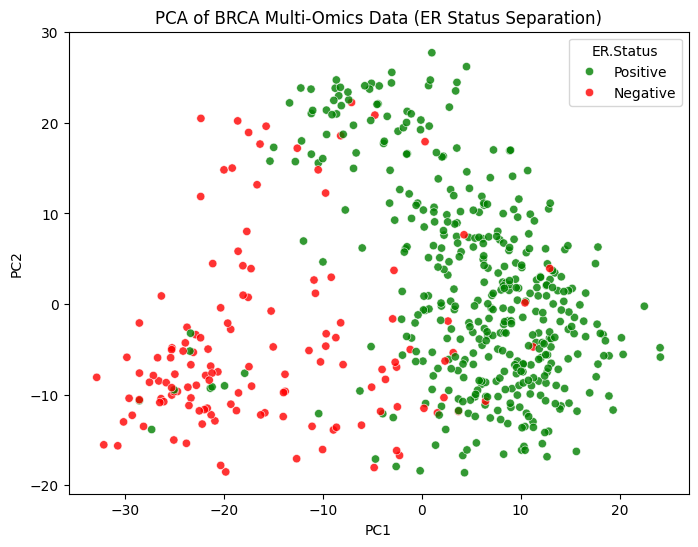

Explained variance ratio: [0.08278482 0.06188028]


In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.decomposition import PCA

# PCA
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)

# Dataframe for plotting
pca_df = pd.DataFrame({
    "PC1": X_pca[:, 0],
    "PC2": X_pca[:, 1],
    "ER.Status": ["Positive" if val == 1 else "Negative" for val in y]
})

# Scatter plot
plt.figure(figsize=(8,6))
sns.scatterplot(data=pca_df, x="PC1", y="PC2", hue="ER.Status",
                palette={"Positive": "green", "Negative": "red"}, alpha=0.8)
plt.title("PCA of BRCA Multi-Omics Data (ER Status Separation)")
plt.savefig("results/PCA.png", dpi=150, bbox_inches="tight")
plt.show()

print("Explained variance ratio:", pca.explained_variance_ratio_)

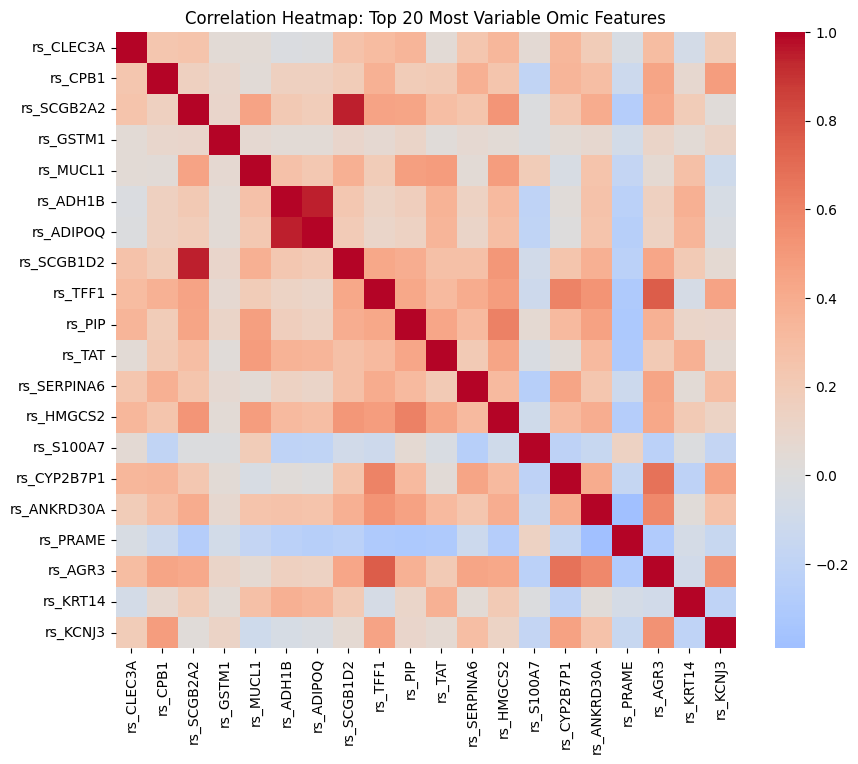

In [22]:
# Computing variance per feature
variances = X.var().sort_values(ascending=False)

# Selecting top 20 most variable features
top_var_features = variances.head(20).index

# Computing correlation matrix
corr = X[top_var_features].corr()

# Plotting heatmap
plt.figure(figsize=(10,8))
sns.heatmap(corr, cmap="coolwarm", center=0)
plt.title("Correlation Heatmap: Top 20 Most Variable Omic Features")
plt.savefig("results/correlation_heatmap.png", dpi=150, bbox_inches="tight")
plt.show()

In [25]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Splitting data (80/20)
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled, y, test_size=0.2, stratify=y, random_state=42)

# Training logistic regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train, y_train)

# Evaluation
y_pred = lr.predict(X_test)
acc = accuracy_score(y_test, y_pred)
print("Logistic Regression Accuracy:", round(acc, 3))
print("Classification Report:", classification_report(y_test, y_pred))

Logistic Regression Accuracy: 0.909
Classification Report:               precision    recall  f1-score   support

           0       0.81      0.81      0.81        27
           1       0.94      0.94      0.94        83

    accuracy                           0.91       110
   macro avg       0.88      0.88      0.88       110
weighted avg       0.91      0.91      0.91       110



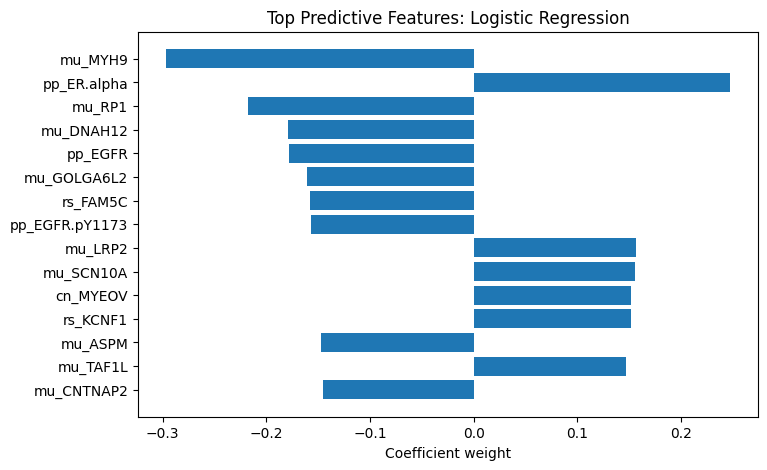

In [26]:
coef = lr.coef_[0]
top_idx = np.argsort(np.abs(coef))[-15:][::-1]
top_features = X.columns[top_idx]
top_values = coef[top_idx]

plt.figure(figsize=(8,5))
plt.barh(top_features, top_values)
plt.gca().invert_yaxis()
plt.title("Top Predictive Features: Logistic Regression")
plt.xlabel("Coefficient weight")
plt.savefig("results/LR_features.png", dpi=150, bbox_inches="tight")
plt.show()

In [27]:
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from sklearn.svm import SVC

In [28]:
# Random Forest
rf = RandomForestClassifier(n_estimators=300, random_state=42)
rf.fit(X_train, y_train)
rf_pred = rf.predict(X_test)
rf_acc = accuracy_score(y_test, rf_pred)
print("Random Forest Accuracy:", round(rf_acc, 3))

Random Forest Accuracy: 0.891


In [29]:
# XGBoost
xgb = XGBClassifier(n_estimators=300, learning_rate=0.05, max_depth=4,
                    random_state=42, eval_metric="logloss")
xgb.fit(X_train, y_train)
xgb_pred = xgb.predict(X_test)
xgb_acc = accuracy_score(y_test, xgb_pred)
print("XGBoost Accuracy:", round(xgb_acc, 3))

XGBoost Accuracy: 0.918


In [30]:
# SVM — probability=True required for ROC-AUC
svm = SVC(kernel="rbf", C=1, gamma="scale", probability=True)
svm.fit(X_train, y_train)
svm_pred = svm.predict(X_test)
svm_acc = accuracy_score(y_test, svm_pred)
print("SVM Accuracy:", round(svm_acc, 3))

SVM Accuracy: 0.9


In [31]:
print(f"Logistic Regression Accuracy: {acc:.3f}")
print(f"Random Forest Accuracy:       {rf_acc:.3f}")
print(f"XGBoost Accuracy:             {xgb_acc:.3f}")
print(f"SVM Accuracy:                 {svm_acc:.3f}")

Logistic Regression Accuracy: 0.909
Random Forest Accuracy:       0.891
XGBoost Accuracy:             0.918
SVM Accuracy:                 0.900


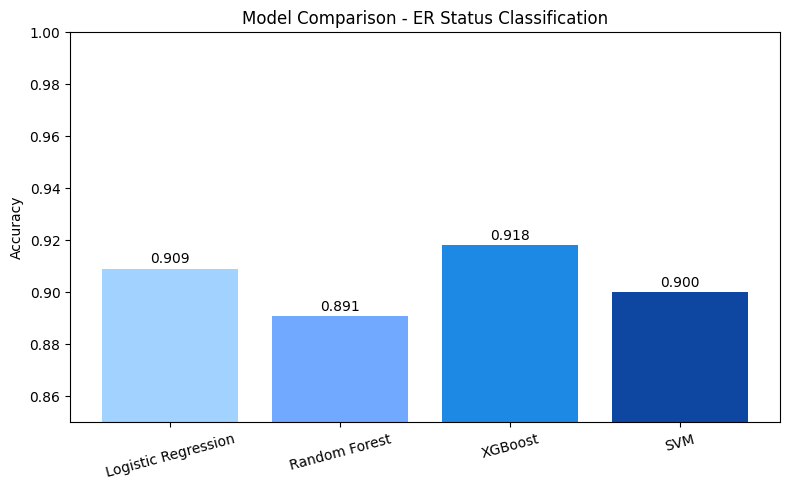

In [32]:
model_names = ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]
accuracies = [acc, rf_acc, xgb_acc, svm_acc]
colors = ["#a2d2ff", "#70a9ff", "#1e88e5", "#0d47a1"]

plt.figure(figsize=(8,5))
plt.bar(model_names, accuracies, color=colors)
plt.ylabel("Accuracy")
plt.title("Model Comparison - ER Status Classification")
plt.ylim(0.85, 1.0)

for i, v in enumerate(accuracies):
    plt.text(i, v+0.002, f"{v:.3f}", ha="center", fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/model_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

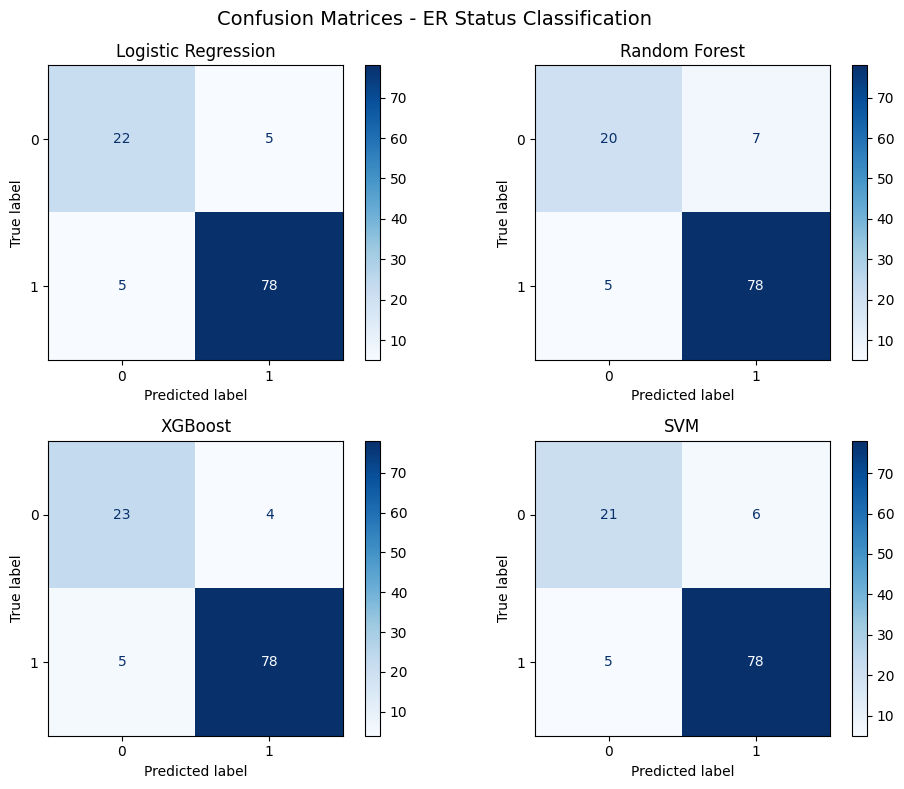

In [33]:
from sklearn.metrics import ConfusionMatrixDisplay

models_dict = {
    "Logistic Regression": (lr, y_pred),
    "Random Forest": (rf, rf_pred),
    "XGBoost": (xgb, xgb_pred),
    "SVM": (svm, svm_pred)
}

fig, axes = plt.subplots(2, 2, figsize=(10, 8))
axes = axes.ravel()

for i, (name, (model, preds)) in enumerate(models_dict.items()):
    ConfusionMatrixDisplay.from_predictions(y_test, preds, ax=axes[i], cmap="Blues")
    axes[i].set_title(name)

plt.suptitle("Confusion Matrices - ER Status Classification", fontsize=14)
plt.tight_layout()
plt.savefig("results/confusion_matrices.png", dpi=150, bbox_inches="tight")
plt.show()

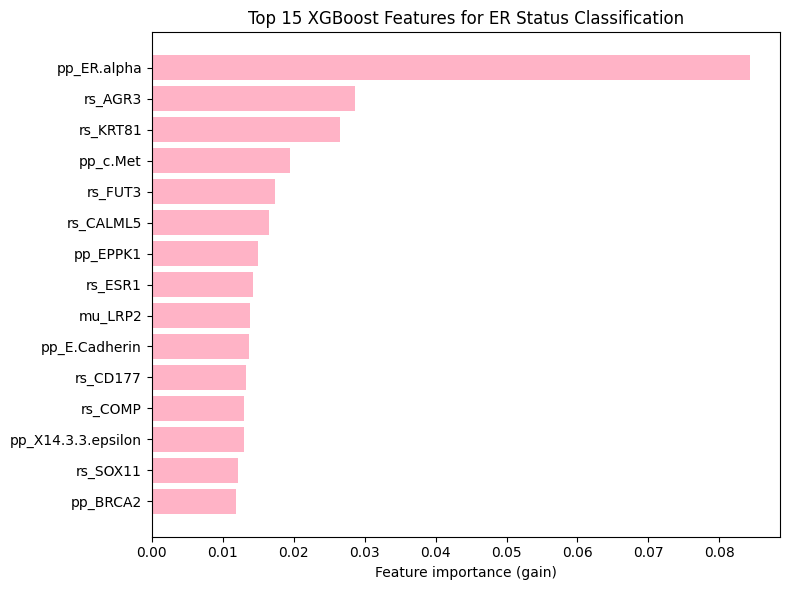

In [34]:
importances = xgb.feature_importances_
indices = np.argsort(importances)[::-1][:15]
feature_names = X.columns[indices]
top_importances = importances[indices]

plt.figure(figsize=(8,6))
plt.barh(range(len(top_importances)), top_importances[::-1], color="#ffb3c6")
plt.yticks(range(len(top_importances)), feature_names[::-1])
plt.xlabel("Feature importance (gain)")
plt.title("Top 15 XGBoost Features for ER Status Classification")
plt.tight_layout()
plt.savefig("results/xgb_feature_importance.png", dpi=150, bbox_inches="tight")
plt.show()

In [35]:
import shap

# TreeExplainer for XGBoost
explainer = shap.TreeExplainer(xgb)
shap_values = explainer.shap_values(X_test)
print("SHAP values shape:", shap_values.shape)

SHAP values shape: (110, 1937)


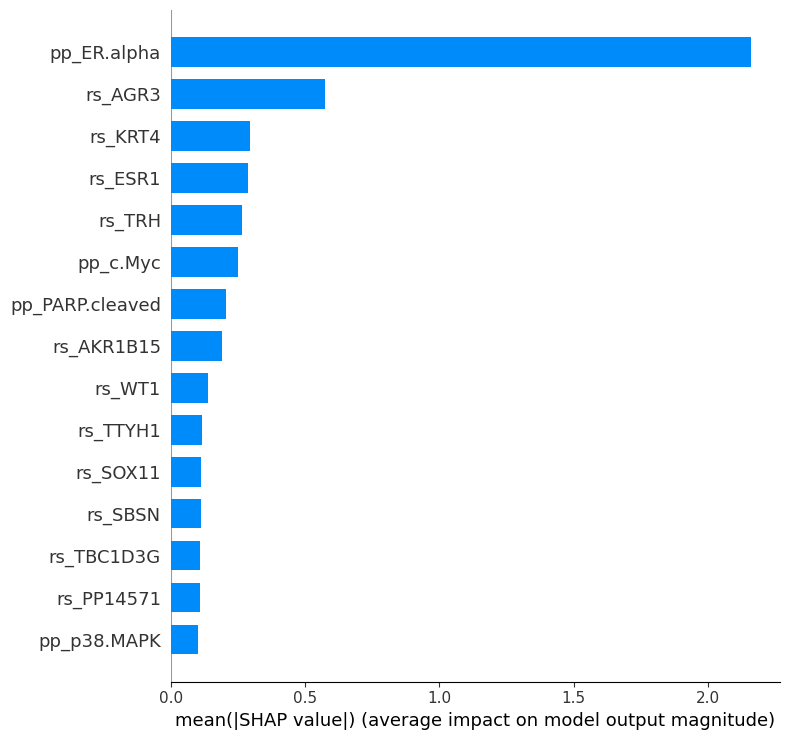

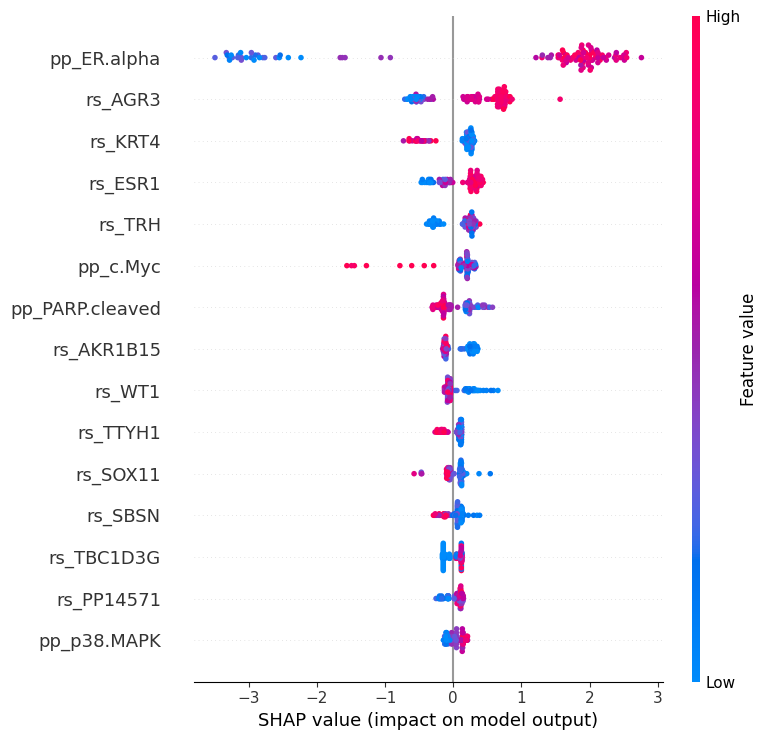

In [36]:
X_test_df = pd.DataFrame(X_test, columns=X.columns)

# Bar summary plot
shap.summary_plot(
    shap_values,
    features=X_test_df,
    feature_names=X_test_df.columns,
    plot_type="bar",
    max_display=15
)

# Beeswarm plot with feature direction
shap.summary_plot(
    shap_values,
    features=X_test_df,
    feature_names=X_test_df.columns,
    max_display=15
)

In [37]:
from sklearn.model_selection import cross_val_score, StratifiedKFold

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

cv_models = {
    "Logistic Regression": lr,
    "Random Forest": rf,
    "XGBoost": xgb,
    "SVM": svm
}

cv_results = {}
for name, model in cv_models.items():
    scores = cross_val_score(model, X_scaled, y, cv=cv, scoring="accuracy")
    cv_results[name] = scores
    print(f"{name}: Mean = {scores.mean():.3f} (+/- {scores.std():.3f})")

Logistic Regression: Mean = 0.907 (+/- 0.018)
Random Forest: Mean = 0.927 (+/- 0.012)
XGBoost: Mean = 0.933 (+/- 0.016)
SVM: Mean = 0.914 (+/- 0.022)


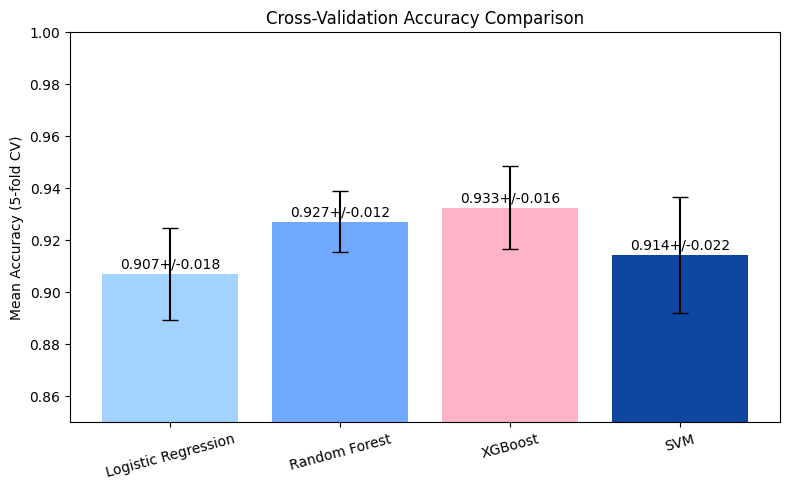

In [38]:
means = [cv_results[m].mean() for m in ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]]
stds  = [cv_results[m].std()  for m in ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]]
model_names = ["Logistic Regression", "Random Forest", "XGBoost", "SVM"]

plt.figure(figsize=(8,5))
plt.bar(model_names, means, yerr=stds, capsize=6,
        color=["#a2d2ff", "#70a9ff", "#ffb3c6", "#0d47a1"])
plt.ylabel("Mean Accuracy (5-fold CV)")
plt.title("Cross-Validation Accuracy Comparison")
plt.ylim(0.85, 1.0)

for i, v in enumerate(means):
    plt.text(i, v+0.002, f"{v:.3f}+/-{stds[i]:.3f}", ha="center", fontsize=10)

plt.xticks(rotation=15)
plt.tight_layout()
plt.savefig("results/cv_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

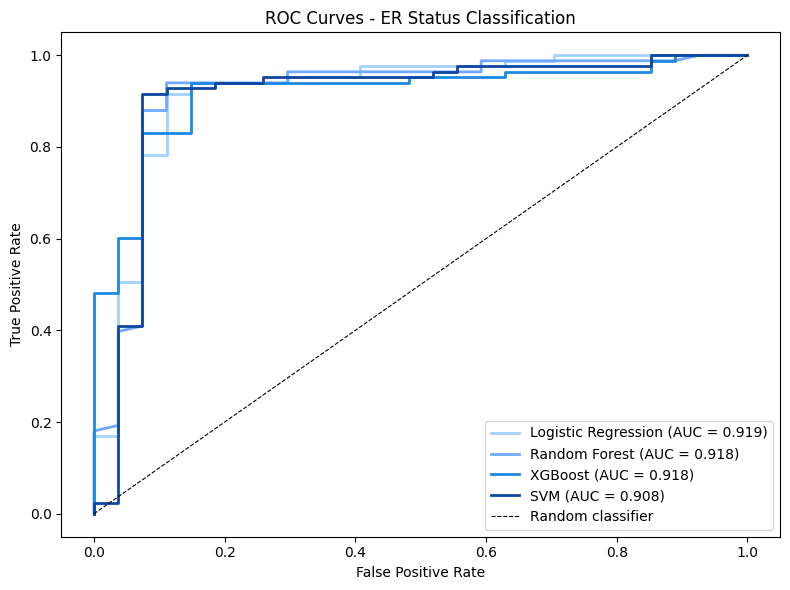

In [39]:
from sklearn.metrics import roc_curve, auc

# Binary classification — get probability for positive class (ER+)
models_proba = {
    "Logistic Regression": lr.predict_proba(X_test)[:, 1],
    "Random Forest":       rf.predict_proba(X_test)[:, 1],
    "XGBoost":             xgb.predict_proba(X_test)[:, 1],
    "SVM":                 svm.predict_proba(X_test)[:, 1]
}

plt.figure(figsize=(8, 6))
colors = ["#a2d2ff", "#70a9ff", "#1e88e5", "#0d47a1"]

for (name, y_prob), color in zip(models_proba.items(), colors):
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    roc_auc = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f"{name} (AUC = {roc_auc:.3f})", color=color, linewidth=2)

plt.plot([0, 1], [0, 1], "k--", linewidth=0.8, label="Random classifier")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves - ER Status Classification")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("results/roc_curves.png", dpi=150, bbox_inches="tight")
plt.show()